6で作成したチャープ信号に対してDFT (numpy.fft.rfftで良い) を施し， 横軸を周波数 [Hz] として振幅スペクトルをプロットしなさい．

In [1]:
from pathlib import Path
import numpy as np
import soundfile as sf

output_dir = Path("outputs/audio")
output_dir.mkdir(parents=True, exist_ok=True)

fs = 16000
T = 5.0
f0 = 100.0
f1 = 4000.0
amplitude = 0.5
k = (f1 - f0) / T

chirp_path = output_dir / "06_chirp_100_to_4000hz.wav"

if chirp_path.exists():
    x, sr = sf.read(chirp_path, dtype="float32")
    fs = sr
else:
    t = np.arange(int(fs * T)) / fs
    x = amplitude * np.sin(2 * np.pi * (f0 * t + 0.5 * k * t**2))
    sf.write(chirp_path, x, fs)

print(f"使用する音声: {chirp_path}")
print(f"fs = {fs} Hz")
print(f"samples = {len(x)}")
print(f"duration = {len(x) / fs:.2f} s")


使用する音声: outputs/audio/06_chirp_100_to_4000hz.wav
fs = 16000 Hz
samples = 80000
duration = 5.00 s


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

figure_dir = Path("outputs/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

window = np.hanning(len(x))
X = np.fft.rfft(x * window)
freq = np.fft.rfftfreq(len(x), d=1 / fs)

magnitude = np.abs(X)
magnitude_db = 20 * np.log10(np.maximum(magnitude, 1e-12))

peak_frequency = freq[np.argmax(magnitude)]
print(f"最大振幅の周波数: {peak_frequency:.2f} Hz")


最大振幅の周波数: 2048.20 Hz


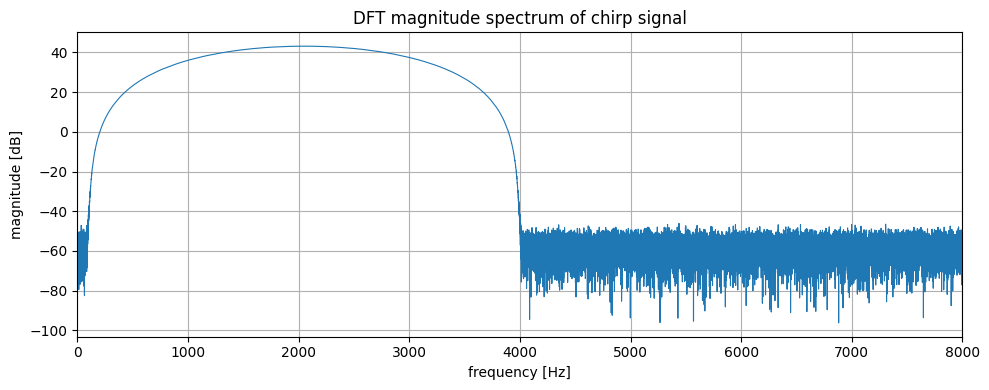

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(freq, magnitude_db, linewidth=0.8)
plt.xlabel("frequency [Hz]")
plt.ylabel("magnitude [dB]")
plt.title("DFT magnitude spectrum of chirp signal")
plt.xlim(0, fs / 2)
plt.grid(True)
plt.tight_layout()
plt.savefig(figure_dir / "07_chirp_dft_spectrum.png", dpi=150)
plt.show()
